# Car Price Analysis using Python

## Objective
Analyze car dataset to understand factors affecting selling price.

## Tools Used
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
##Libraries are imported for data manipulation, visualization, and analysis.

In [34]:
os.getcwd()

'C:\\Users\\ACER'

In [35]:
cars=pd.read_csv("Car_details.csv")
##The dataset is loaded successfully into a pandas DataFrame for further analysis.

In [70]:
cars.head()

,year,selling_price,km_driven,seats,number_of_year,fuel_Diesel,fuel_LPG,fuel_Petrol,seller_type_Individual,seller_type_Trustmark Dealer,transmission_Manual,owner_Fourth & Above Owner,owner_Second Owner,owner_Test Drive Car,owner_Third Owner
0,2014,450000,145500,5.0,12,True,False,False,True,False,True,False,False,False,False
1,2014,370000,120000,5.0,12,True,False,False,True,False,True,False,True,False,False
2,2006,158000,140000,5.0,20,False,False,True,True,False,True,False,False,False,True
3,2010,225000,127000,5.0,16,True,False,False,True,False,True,False,False,False,False
4,2007,130000,120000,5.0,19,False,False,True,True,False,True,False,False,False,False


In [37]:
cars.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           8128 non-null   object 
 1   year           8128 non-null   int64  
 2   selling_price  8128 non-null   int64  
 3   km_driven      8128 non-null   int64  
 4   fuel           8128 non-null   object 
 5   seller_type    8128 non-null   object 
 6   transmission   8128 non-null   object 
 7   owner          8128 non-null   object 
 8   mileage        7907 non-null   object 
 9   engine         7907 non-null   object 
 10  max_power      7913 non-null   object 
 11  torque         7906 non-null   object 
 12  seats          7907 non-null   float64
dtypes: float64(1), int64(3), object(9)
memory usage: 825.6+ KB


In [38]:
cars.isnull().sum()

name               0
year               0
selling_price      0
km_driven          0
fuel               0
seller_type        0
transmission       0
owner              0
mileage          221
engine           221
max_power        215
torque           222
seats            221
dtype: int64

In [39]:
cars.dropna(inplace=True)

In [40]:
cars.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7906 entries, 0 to 8127
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           7906 non-null   object 
 1   year           7906 non-null   int64  
 2   selling_price  7906 non-null   int64  
 3   km_driven      7906 non-null   int64  
 4   fuel           7906 non-null   object 
 5   seller_type    7906 non-null   object 
 6   transmission   7906 non-null   object 
 7   owner          7906 non-null   object 
 8   mileage        7906 non-null   object 
 9   engine         7906 non-null   object 
 10  max_power      7906 non-null   object 
 11  torque         7906 non-null   object 
 12  seats          7906 non-null   float64
dtypes: float64(1), int64(3), object(9)
memory usage: 864.7+ KB


In [41]:
cars['name'].unique()

array(['Maruti Swift Dzire VDI', 'Skoda Rapid 1.5 TDI Ambition',
       'Honda City 2017-2020 EXi', ..., 'Tata Nexon 1.5 Revotorq XT',
       'Ford Freestyle Titanium Plus Diesel BSIV',
       'Toyota Innova 2.5 GX (Diesel) 8 Seater BS IV'],
      shape=(1982,), dtype=object)

In [42]:
cars['name'].nunique()

1982

In [43]:
cars.drop(columns='name',inplace=True)

In [44]:
cars.head()

,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0
3,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
4,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0


## Data Cleaning

In [60]:
cars['mileage']=cars['mileage'].astype(str).str.split().str[0].astype(float)
cars['engine']=cars['engine'].astype(str).str.split().str[0].astype(float)
cars['max_power']=cars['max_power'].astype(str).str.split().str[0].astype(float)

In [ ]:
cars.drop(columns=['torque'],inplace=True)

In [74]:
cars.drop(columns=['mileage','engine','max_power'],errors='ignore',inplace=True)

## Feature Engineering

In [46]:
import datetime

current_year=datetime.datetime.now().year
cars['number_of_year']=current_year-cars['year']

##Created a new feature 'number_of_year' to represent the age of the car.

In [47]:
cars.head()

,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats,number_of_year
0,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0,12
1,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0,12
2,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0,20
3,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0,16
4,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0,19


In [48]:
cars.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7906 entries, 0 to 8127
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   year            7906 non-null   int64  
 1   selling_price   7906 non-null   int64  
 2   km_driven       7906 non-null   int64  
 3   fuel            7906 non-null   object 
 4   seller_type     7906 non-null   object 
 5   transmission    7906 non-null   object 
 6   owner           7906 non-null   object 
 7   mileage         7906 non-null   object 
 8   engine          7906 non-null   object 
 9   max_power       7906 non-null   object 
 10  torque          7906 non-null   object 
 11  seats           7906 non-null   float64
 12  number_of_year  7906 non-null   int64  
dtypes: float64(1), int64(4), object(8)
memory usage: 864.7+ KB


## Encoding

In [ ]:
cars=pd.get_dummies(cars,drop_first=True)

In [72]:
cars.head()

,year,selling_price,km_driven,seats,number_of_year,fuel_Diesel,fuel_LPG,fuel_Petrol,seller_type_Individual,seller_type_Trustmark Dealer,transmission_Manual,owner_Fourth & Above Owner,owner_Second Owner,owner_Test Drive Car,owner_Third Owner
0,2014,450000,145500,5.0,12,True,False,False,True,False,True,False,False,False,False
1,2014,370000,120000,5.0,12,True,False,False,True,False,True,False,True,False,False
2,2006,158000,140000,5.0,20,False,False,True,True,False,True,False,False,False,True
3,2010,225000,127000,5.0,16,True,False,False,True,False,True,False,False,False,False
4,2007,130000,120000,5.0,19,False,False,True,True,False,True,False,False,False,False


In [71]:
cars.columns
cars.select_dtypes(include='object')

""
0
1
2
3
4
...
8123
8124
8125
8126


## Exploratory Data Analysis (EDA)

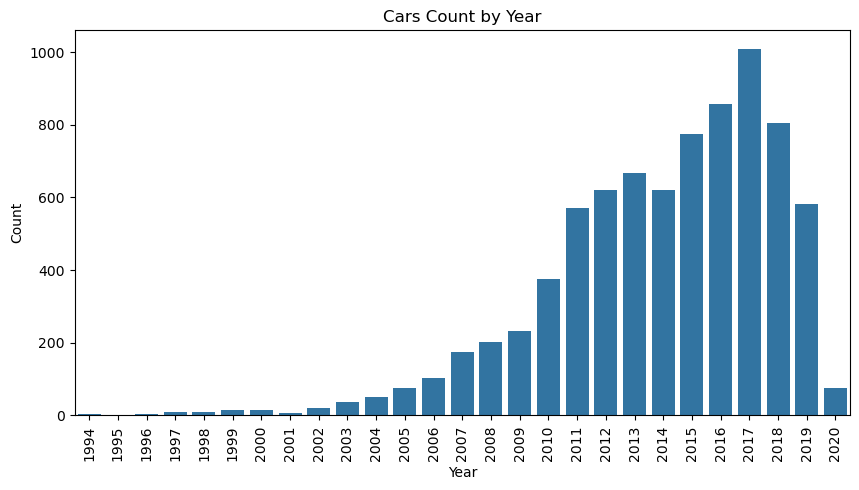

In [45]:
plt.figure(figsize = (10,5))
sns.countplot(x = 'year', data=cars)
plt.title("Cars Count by Year")
plt.xlabel("Year")
plt.ylabel("Count")
plt.xticks(rotation=90)
plt.show()

##Most cars in the dataset are from recent years, indicating higher resale activity.

In [49]:
cars['fuel'].unique()

array(['Diesel', 'Petrol', 'LPG', 'CNG'], dtype=object)

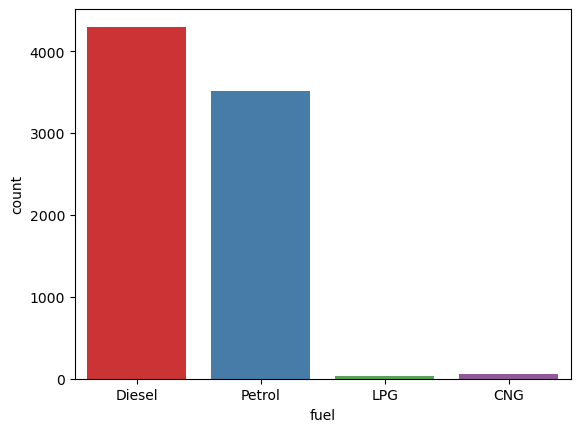

In [50]:
sns.countplot(x=cars['fuel'],data =cars,hue="fuel",palette='Set1',legend=False)
plt.show()

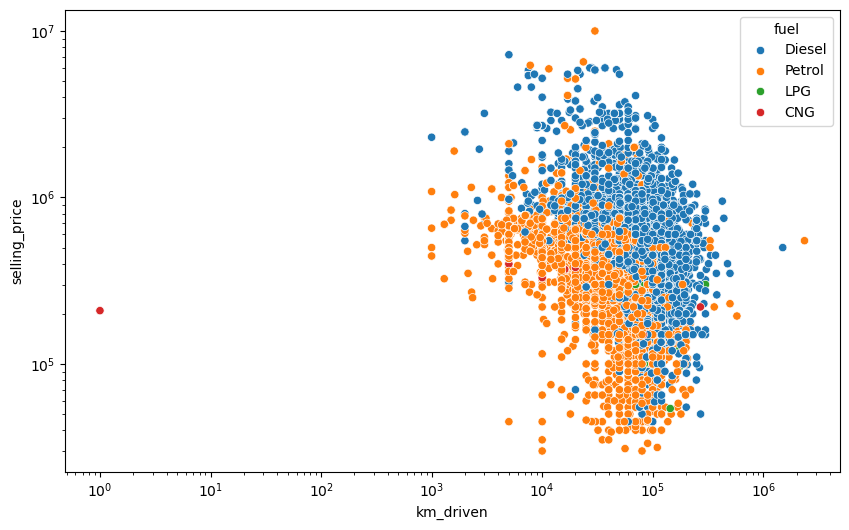

In [51]:
plt.figure(figsize=(10,6))
plt.xscale('log')
plt.yscale('log')

sns.scatterplot(x=cars['km_driven'],y=cars['selling_price'],hue=cars['fuel'])
plt.show()

##Cars with lower kilometers driven tend to have higher selling prices.

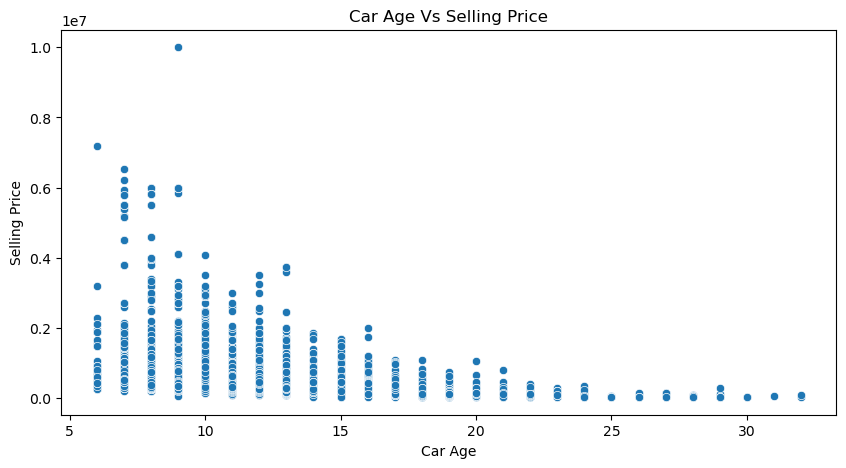

In [52]:
plt.figure(figsize=(10,5))
sns.scatterplot(x="number_of_year",y="selling_price",data=cars)
plt.title("Car Age Vs Selling Price")
plt.xlabel("Car Age")
plt.ylabel("Selling Price")
plt.show()

##Older cars tend to have lower selling prices, showing depreciation over time.

In [53]:
cars['seller_type'].unique()

array(['Individual', 'Dealer', 'Trustmark Dealer'], dtype=object)

seller_type
Dealer              1107
Individual          6563
Trustmark Dealer     236
dtype: int64




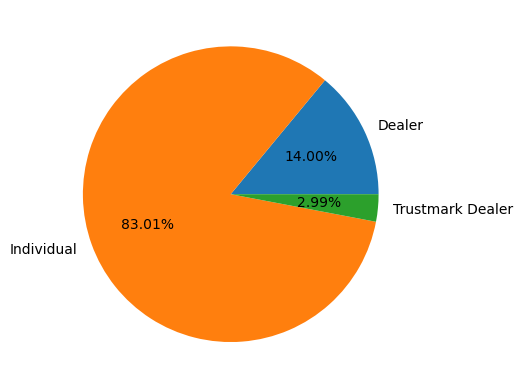

In [54]:
seller=cars.groupby('seller_type').size()
print(seller)
print('\n')

plt.pie(seller,labels=seller.index,autopct='%1.2f%%')
plt.show()

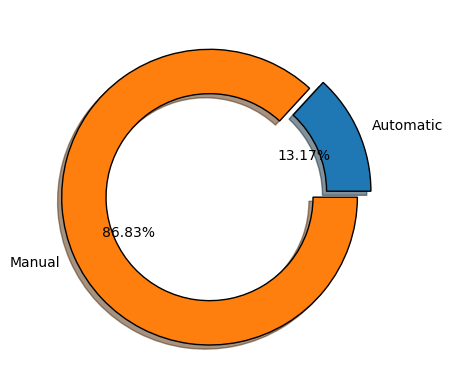

In [55]:
cars['transmission'].unique()
print('\n')
trans=cars.groupby('transmission').size()
trans.plot(kind='pie',autopct='%1.2f%%',wedgeprops={'width':0.3,'edgecolor':'black'},shadow='bool',explode=[0.05]*len(trans))
plt.show()

In [56]:
cars['owner'].unique()

array(['First Owner', 'Second Owner', 'Third Owner',
       'Fourth & Above Owner', 'Test Drive Car'], dtype=object)

owner
First Owner             5215
Second Owner            2016
Third Owner              510
Fourth & Above Owner     160
Test Drive Car             5
Name: count, dtype: int64




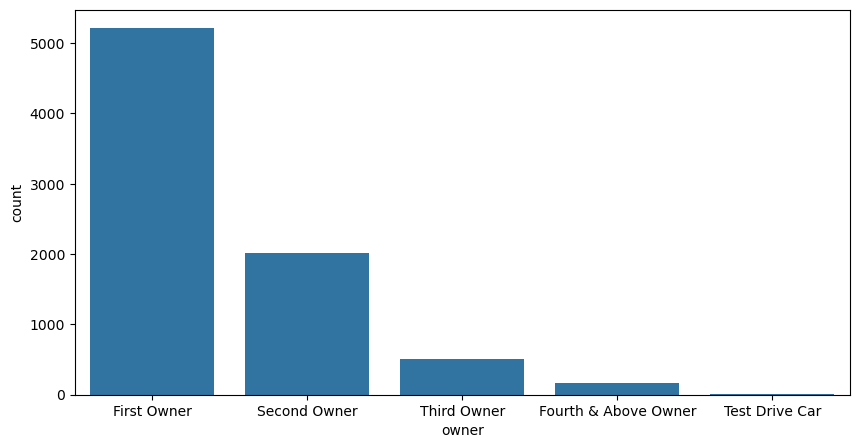

In [57]:
print(cars['owner'].value_counts())
print('\n')
plt.figure(figsize=(10,5))
sns.countplot(x=cars['owner'])
plt.show()

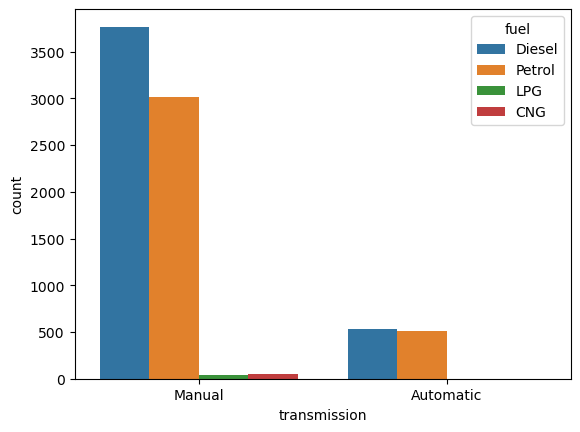

In [58]:

sns.countplot(x=cars['transmission'],hue=cars['fuel'])
plt.show()

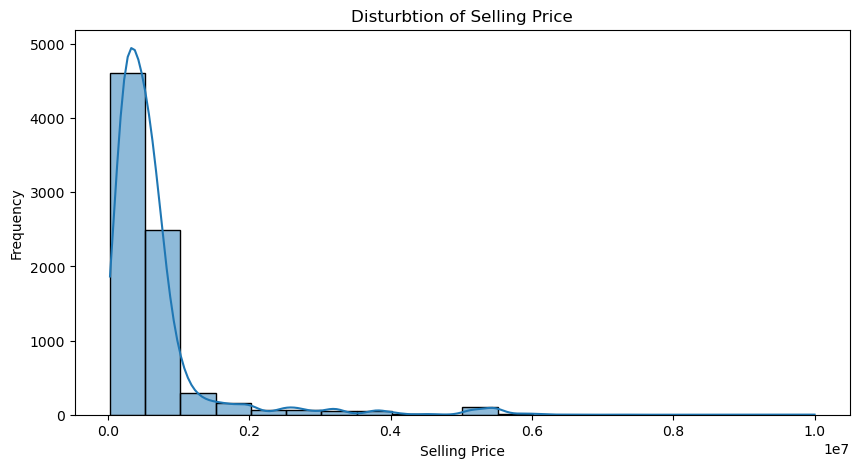

In [69]:
plt.figure(figsize=(10,5))
sns.histplot(cars['selling_price'],bins=20,kde=True)
plt.title("Disturbtion of Selling Price")
plt.xlabel("Selling Price")
plt.ylabel("Frequency")
plt.show()

##Most cars fall within a lower to mid price range, with a right-skewed distribution indicating fewer high-priced cars.

## Final Insights

- Most cars in the dataset are from recent years, indicating active resale of newer vehicles
- Cars with lower kilometers driven tend to have higher selling prices
- Selling price decreases significantly as car age increases, showing clear depreciation
- Most cars fall within the lower to mid price range
- Newer cars show higher variation in price compared to older cars